# Assignment 7

### <span style="color:chocolate"> Submission requirements </span>

Your work will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:
    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).

Additional note:

* You can complete this assignment using either your local machine or Google Colab. Your solution for this assignment should be able to run on the <span style="color:red">FREE version</span> of Google Colab. If you find that you need to upgrade to the paid version, it indicates that there is an inefficiency in your code.
---

#### ``Objectives``
1. Implement a Decision Forest for land cover classification

#### ``Motivation``

Land cover classification using machine learning (ML) techniques is important for several reasons, spanning environmental monitoring, resource management, urban planning, disaster response, and scientific research. 

#### ``Data``

In this assignment, you will use the EuroSAT dataset, consisting of Sentinel-2 RGB satellite images of 10 classes with 27000 labeled and geo-referenced samples. 

The dataset is hosted by [TensorFlow Data Collections](https://www.tensorflow.org/datasets/catalog/eurosat). To avoid any data versioning issues, we have downloaded the data for you (please see below).

`Download` link: [images + labels](https://drive.google.com/file/d/131GuYn092OlWKGopsT8arQoDreneU7SZ/view?usp=share_link). Once you unzip the file, you will see that the name of each subfolder represents the land cover classes.

---

### Import libraries

In [1]:
import numpy as np
import pandas as pd
import random

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

from sklearn.preprocessing import LabelEncoder
from sklearn import ensemble
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

import os
import shutil
import pathlib
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore", category=UserWarning) #used to supress the tf version warning. 

# FILL IN CODE HERE #
DATA_PATH = "datasets/EuroSAT" # replace with your path

^ make sure to replace DATA_PATH with the path to the directory where you saved the data.

---
### Step 1: Data ingestion

#### <span style="color:chocolate"> Exercise 1 (10 points) </span>

Let's load the 2D images and their corresponding labels. Implement the <span style="color:chocolate">load_data()</span> function below according to the following guidelines:
- to read label and image names: use the <span style="color:chocolate">os</span> library (in particular the <span style="color:chocolate">os.listdir()</span> and <span style="color:chocolate">os.path.join()</span> methods);
- to load an image: use the <span style="color:chocolate">load_image()</span> method (see list of imported libraries);
- to transform images to arrays: use the <span style="color:chocolate">img_to_array()</span> method (see list of imported libraries).

In [2]:
def load_data(path_to_data):
    '''Load 2D images and their corresponding labels
    Parameters:
    path_to_data (str): This is the path to data
    
    Returns:
    images (np.ndarray): A numpy array of shape (N, 64, 64, 3)
    labels (np.ndarray): A numpy array of shape (N)
    
    '''
    ## load images and labels
    images = []
    labels = []
    
    class_names = sorted(os.listdir(path_to_data))
    
    for label_idx, class_name in enumerate(class_names):
        class_path = os.path.join(path_to_data, class_name)
        if not os.path.isdir(class_path):
            continue
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            img = load_img(img_path, target_size = (64, 64))
            img_array = img_to_array(img)

            images.append(img_array)
            labels.append(label_idx)

    images = np.array(images)
    labels = np.array(labels)
    
    return images, labels

In [3]:
# Load images and labels. Print shapes

images, labels = load_data(DATA_PATH)
print("Shape of images ", images.shape)
print("Shape of labels ", labels.shape)

Shape of images  (27000, 64, 64, 3)
Shape of labels  (27000,)


---
### Step 2: Exploratory data analysis (EDA)

#### <span style="color:chocolate"> Exercise 2 (10 points) </span>

Plot the land cover class distribution. Are the classes balanced?

Note: It's acceptable to plot the distribution of classes before splitting your data into training, validation, and test sets. Doing so does not compromise the "blindness" of the test data. Why?

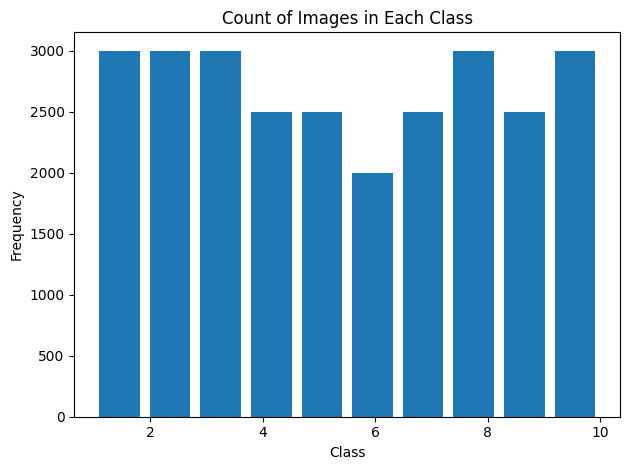

In [4]:
class_labels = np.unique(labels)
# 10 class labels
plt.hist(labels, bins=10, rwidth=0.8)
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.title("Count of Images in Each Class")
plt.tight_layout()
plt.show()

Comment on class balance: Viewing the distribution of class labels does not compromise "blindness" of test data because we will randomly shuffle data before splitting into x and y so we won't know what data is in our test set until we do the split. After the split, we cannot check x_test or y_test, but before it is okay to get a general sense of what class balance looks like. Comment on class balance- the classes appear mostly balanced to me but class 6 clearly has the lowest number of images: about 2000 versus the highest of about 3000 images in other classes like classes 1,2,3,8, and 10. So the least represented  class is class 6- this could cause problems in our modeling later. Other classes like 4,5,7,and 9 fall somwhere between 6 and the rest in terms of counts of images in each class in our dataset: they appear to have about 2500 images in those classes. SO our dataset is slightly imbalanced but not overly imbalanced. Hopefully our decision tree can handle the slight imbalance in images for certain classes.

#### <span style="color:chocolate"> Exercise 3 (10 points) </span>

Inspect (print) one image from each class. What land classes do you think a Decision Tree classifier is more likely to confuse?

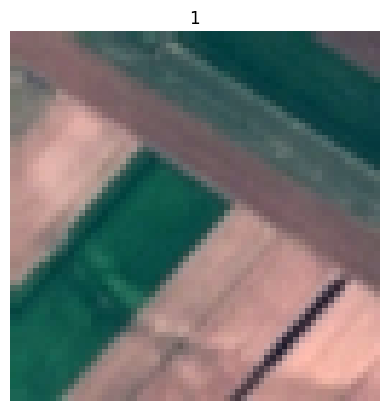

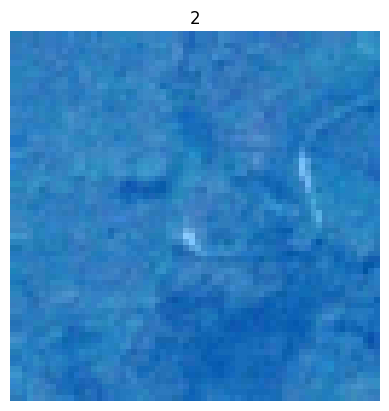

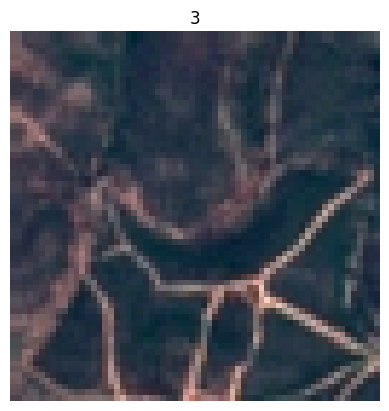

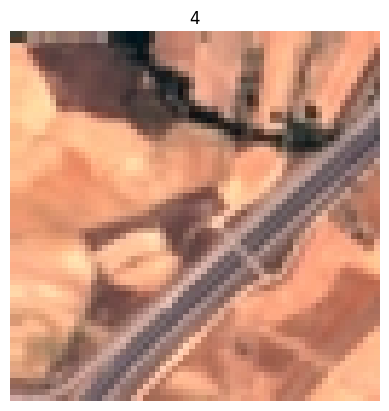

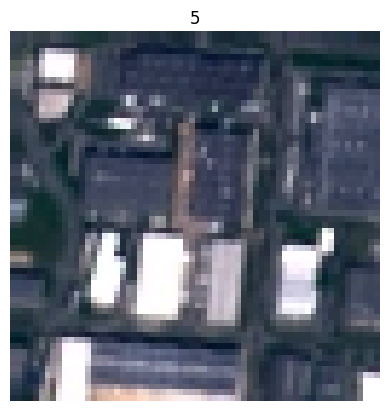

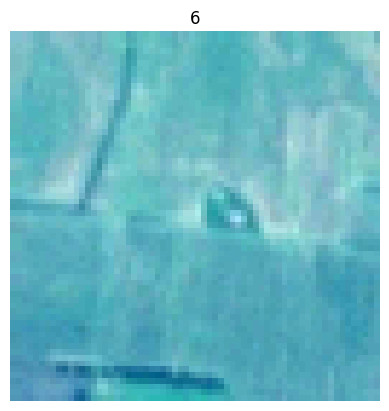

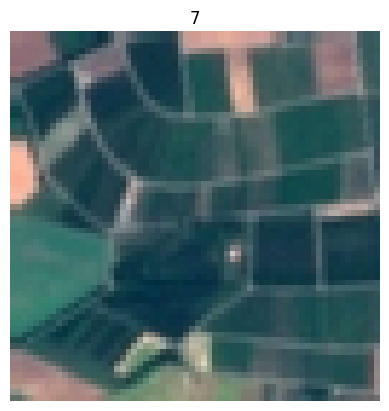

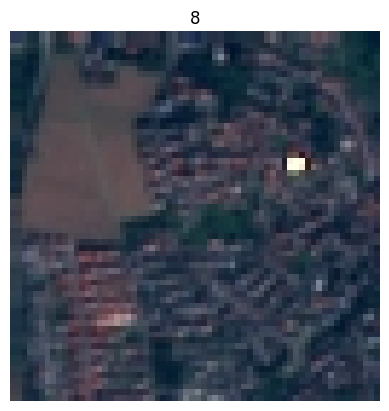

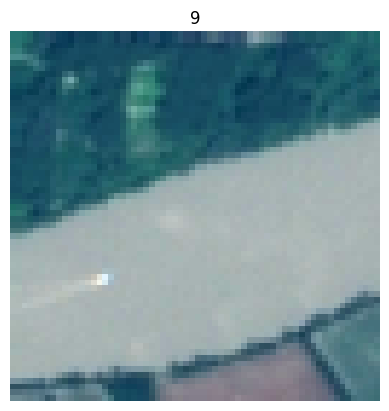

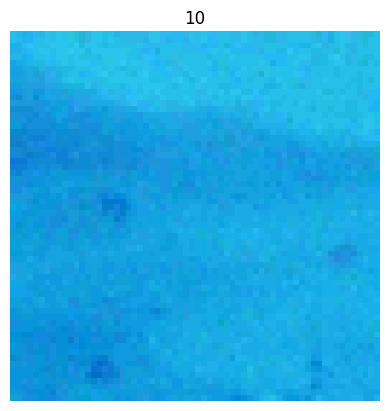

In [30]:
class_labels = np.unique(labels)
# Class labels = list from 1 to 10
for i, class_id in enumerate(class_labels):
    
    class_indices = np.where(labels == class_id)[0][0]

    image_test = array_to_img(images[class_indices])

    plt.imshow(image_test)
    plt.title(class_labels[i])
    plt.axis("off")
    plt.show()

Most confused land classes: To me, classes 2 and 10 look similar- similar grid patterns and colors to the data. Seems many nodes could lead the decision tree to classify these two as the same. Classes 5 and 8 also look to share lots of characteristics that could appear in our decision tree nodes so they might be mixed up... Classes like 9, 7, and 4 look like they have somewhat distinct features so hopefully our decision tree is able to cleanly classify these- to me, those classes seem like they will be the least confusing classes to our model because they have distinct features like a big block that is a body of water or distinct brown colorings or no roads (just what appears to be trees).

---
### Step 3: Data preprocessing

Encode labels

In [7]:
encoder = LabelEncoder().fit(list(set(labels))) # fit on unique labels
encoded_labels = encoder.transform(labels) # apply to labels array (will get labels from 0 to 9)
encoded_labels_classes = list(encoder.classes_) # store mapping generated by the encoder

#### <span style="color:chocolate"> Exercise 4 (10 points) </span>

Create train, validation, and test data. Implement the <span style="color:chocolate">split_data()</span> function below according to the following guidelines:
- shuffle images and labels before spliting the data;
- use a 60/20/20 split.

In [8]:
def split_data(images, labels, split):
    '''Split data into train, validation and test sets.
    
    Parameters:
    images  (np.ndarray): Images of shape (N, 64, 64, 3)
    labels (np.ndarray): Labels of shape (N,)   
    split (tuple): 3 values summing to 1 defining split of train, validation and test sets
    
    Returns:
    X_train (np.ndarray): Train images of shape (N_train, 64, 64, 3)
    y_train (np.ndarray): Train labels of shape (N_train,)
    X_val (np.ndarray): Val images of shape (N_val, 64, 64, 3)
    y_val (np.ndarray): Val labels of shape (N_val,)
    X_test (np.ndarray): Test images of shape (N_test, 64, 64, 3)
    y_test (np.ndarray): Test labels of shape (N_test,)
    
    '''
    # NOTE: Each time you run this cell, you'll re-shuffle the data. The ordering will be the same due to the random seed generator 
    tf.random.set_seed(1234)
    np.random.seed(1234)
    
    # shuffle data
    images = images.copy()
    labels = labels.copy()
    indices = list(range((images.shape[0])))
    shuffled_indices = np.random.permutation(indices)
    images = images[shuffled_indices]
    labels = labels[shuffled_indices]
    
    # create data splits
    X_train, X_temp, y_train, y_temp = train_test_split(images, labels, test_size = (split[1] + split[2]))
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = split[2])
    
    return X_train, y_train, X_val, y_val, X_test, y_test

In [9]:
# define splits
split = (0.6, 0.2, 0.2)

# create train, val, test sets
X_train, y_train, X_val, y_val, X_test, y_test = split_data(images, encoded_labels, split)

# print shapes
print('Shape of train images ', X_train.shape)
print('Shape of train labels ', y_train.shape)

print('Shape of val images ', X_val.shape)
print('Shape of train labels ', y_val.shape)

print('Shape of test images ', X_test.shape)
print('Shape of test labels ', y_test.shape)

Shape of train images  (16200, 64, 64, 3)
Shape of train labels  (16200,)
Shape of val images  (8640, 64, 64, 3)
Shape of train labels  (8640,)
Shape of test images  (2160, 64, 64, 3)
Shape of test labels  (2160,)


#### <span style="color:chocolate"> Exercise 5 (10 points) </span>

Perform image transformation and augmentation. 

<span style="color:green"> Step 1: </span> Implement the <span style="color:chocolate">data_preprocessing()</span> function below according to the following guidelines:

- Applied on training set only: 
    - create additional copies of the training images by applying the following augmentation techniques to each image: adjust brightness by adding DELTA=0.3 to the pixel values, then adjust contrast to CONTRAST_FACTOR=3, then flip left right (Hint: use the methods available in the tf.image module);
    - concatenate the augmented images to the original training images. Note that the train set should be double in size after data augmentation, i.e., 32400 images and labels;
    
    
- Applied on training, validation, and test sets: normalize all pixel values by dividing by 255.0.
    
<span style="color:green"> Step 2: </span> Comment on the importance of adding augmented images to training data (be sure to justify why you don't augment the validation and test sets as well).

In [10]:
def data_preprocessing(X, y, data_partition='train'):
    '''Apply transformations and augmentations to training, validation, and test dat;
    
    Parameters:
    X  (np.ndarray): Images of shape (N, 64, 64, 3)
    y (np.ndarray): Labels of shape (N,)   
    data_partition (str): "train"
    
    Returns:
    X (np.ndarray): Preprocessed images of shape (N, 64, 64, 3)
    y (np.ndarray): Labels of shape (N,)
    
    '''

    CONTRAST_FACTOR = 3
    DELTA = 0.3
    
    # image augmentation on training data
    if data_partition=="train":
        # adjust brightness
        X_augm = tf.image.adjust_brightness(X, delta=DELTA) # ''

        # adjust contrast
        X_augm = tf.image.adjust_contrast(X, contrast_factor=CONTRAST_FACTOR) #''

        # random flip
        X_augm = tf.image.random_flip_left_right(X) # '' 

        # concatenate original X and augmented X_aug data
        X =  np.concatenate([X, X_augm], axis=0) #'' 

        # concatenate y_train (note the label is preserved)
        y_augm = y
        y = tf.concat([y, y_augm],axis=0)

        # shuffle X and y, i.e., shuffle two tensors in the same order
        shuffle = tf.random.shuffle(tf.range(tf.shape(X)[0], dtype=tf.int32))
        X = tf.gather(X, shuffle).numpy() # transform X back to numpy array instead of tensor
        y = tf.gather(y, shuffle).numpy() # transform y back to numpy array instead of tensor
        
        
    # rescale image by dividing each pixel by 255.0 
    X = X/255.0
    
    return X, y

Comment on the importnace of adding augmented images to training data (be sure to justify why you don't augment the validation and test sets as well): We are adding augmented pictures to our model so that our model is able to get clearer features that it can use to set up decision nodes in it's decision tree- we are giving our model the most specific training data we can so it can learn patterns from our training images easier and build a better classification model.

In [11]:
# apply data preprocessing
X_train, y_train = data_preprocessing(X_train, y_train, data_partition='train')
X_val, y_val = data_preprocessing(X_val, y_val, data_partition='val')
X_test, y_test = data_preprocessing(X_test, y_test, data_partition='val')

# print shapes
print('Shape of train images ', X_train.shape)
print('Shape of train labels ', y_train.shape)
print('Shape of val images ', X_val.shape)
print('Shape of test images ', X_test.shape)

2026-02-25 15:10:13.173441: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-02-25 15:10:13.173608: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-02-25 15:10:13.173621: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-02-25 15:10:13.173651: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-25 15:10:13.173667: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Shape of train images  (32400, 64, 64, 3)
Shape of train labels  (32400,)
Shape of val images  (8640, 64, 64, 3)
Shape of test images  (2160, 64, 64, 3)


Reshape training, val, and test data (to be compatible with sklearn Decision Forests)

In [12]:
# compute number of features (multiply RGB features)
features_shape = X_train[:, :, :, 0].shape[1] * X_train.shape[2] * X_train.shape[3]
print('Total number of features used for Decision Forests', features_shape)

# reshape data
X_train_re = X_train.reshape(X_train.shape[0], features_shape)
X_val_re = X_val.reshape(X_val.shape[0], features_shape)
X_test_re = X_test.reshape(X_test.shape[0], features_shape)

# print shapes
print('Shape of train images ', X_train_re.shape)
print('Shape of train labels ', y_train.shape)
print('Shape of val images ', X_val_re.shape)
print('Shape of test images ', X_test_re.shape)

Total number of features used for Decision Forests 12288
Shape of train images  (32400, 12288)
Shape of train labels  (32400,)
Shape of val images  (8640, 12288)
Shape of test images  (2160, 12288)


---
### Step 4: Modeling

#### <span style="color:chocolate"> Exercise 6 (10 points) </span>

Implement a Decision Forest classifier according to the following guidelines (let's call this model our baseline classifier):
    
- Use the <span style="color:chocolate">RandomForestClassifier</span> class available in the <span style="color:chocolate">sklearn.ensemble</span> module;
- Set the following argument values:
    - n_estimators=2,
    - n_jobs=1
    - random_state=7
    - max_depth=8
- Train the model on (X_train_re, y_train) data;
- Evaluate the accuracy of the model on (X_train_re, y_train) and (X_val_re, y_val) data. Comment on model performance on training vs. validation datasets. Does the model generalize well?
- Plot the confusion matrix using (y_val, y_val_pred) data. Comment on the classes that the model confuses the most.

Training accuracy:  0.5277, Val accuracy:  0.4627, Differece:  0.0649


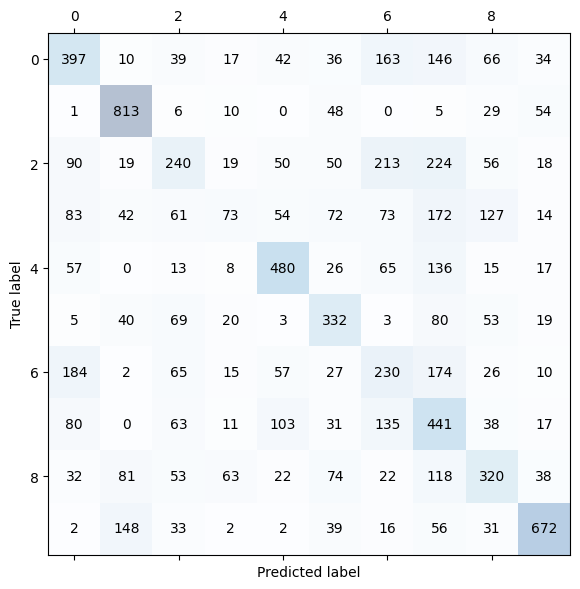

In [13]:
baseline_classifier = ensemble.RandomForestClassifier(n_estimators=2, n_jobs=1,
                                                                random_state=7, max_depth=8)

baseline_model = baseline_classifier.fit(X_train_re, y_train)
y_train_pred = baseline_classifier.predict(X_train_re)
y_val_pred = baseline_classifier.predict(X_val_re)

baseline_train = accuracy_score(y_train, y_train_pred)
baseline_val = accuracy_score(y_val, y_val_pred)

print(f"Training accuracy: {baseline_train: .4f}, Val accuracy: {baseline_val: .4f}, Differece: {(baseline_train - baseline_val): .4f}")

conf_matrix = confusion_matrix(y_val, y_val_pred) # confusion_matrix is available in sklearn.metrics

def confusion_matrix_plot(conf_matrix):
    """ Confusion matrix matplotlib plot
    # param conf_matrix: nested list of TP, TN, FP, FN
    # return: None
    """
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.matshow(conf_matrix, cmap=plt.cm.Blues, alpha=0.3)
    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            ax.text(x=j, y=i, s=conf_matrix[i, j], va='center', ha='center')

    plt.xlabel('Predicted label')
    plt.ylabel('True label')

    plt.tight_layout()
    plt.show()

confusion_matrix_plot(conf_matrix)

Comment on model accuracy on training vs. validation data: The model accuracy for our baseline classifier on our training dataset is pretty low- its about 53%. This is not great, it's only classifying the images correctly about have the time. On our validation dataset, it's slightly worse, predicting images correctly about 46% of the time. So our model is not predicting our validation data set well, it's doing worse on validation dataset than test dataset. 

Does the model generalize well?: The model does not generalize very well but it's not horrible- the validation set has about 7% lower accuracy score than our train dataset. So it's generalization, it's ability to classify unseen data, is not great but it could be worse. 

Comment on the classes that the model confuses the most: classes 1, 7, and 8 appear to have the most incorrect predictions. This isn't exaclty what I predicted after looking at the class images, but it doesn't seem too surprising as looking at those class label images above in my code, they have some similar features.

#### <span style="color:chocolate"> Exercise 7 (20 points) </span>

Implement a Decision Forest classifier that improves the training and validation set accuracy performance of the baseline model implemented above by at least 10% (the more you can improve the better). Also, the performance difference between the training and validation sets should be at most 10%. Be sure to follow these guidelines: 
    
- Use the <span style="color:chocolate">RandomForestClassifier</span> or the <span style="color:chocolate">GradientBoostingClassifier</span> available in the <span style="color:chocolate">sklearn.ensemble</span> module
- Be explicit on how your implementation is different compared to the baseline classifier:
    - different argment values for the baseline model (RandomForestClassifier)?
    - different Decision Forest classifier?
    - different data preprocessing procedure?
    - a combination of the three points above
    - anything else?
- Train the model on (X_train_re, y_train) data.
- Evaluate the model's accuracy on (X_val_re, y_val) data. Comment on training vs. validation performance relative to baseline model.
- Plot confusion matrix using the (y_val, y_val_pred) data. Comment on the classes the model confuses the most relative to the baseline.

Training accuracy:  0.8962, Val accuracy:  0.6362, Differece:  0.2600


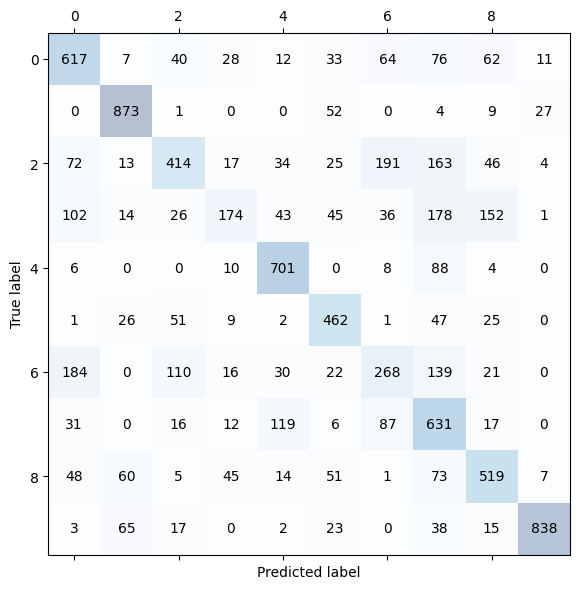

In [31]:
rf_clf2 = ensemble.RandomForestClassifier(n_estimators=100, n_jobs=1,
                                            random_state=7, max_depth=12) # ''

rf_model = rf_clf2.fit(X_train_re, y_train)
y_train_pred = rf_clf2.predict(X_train_re)
y_val_pred = rf_clf2.predict(X_val_re)

rf_train = accuracy_score(y_train, y_train_pred)
rf_val = accuracy_score(y_val, y_val_pred)

print(f"Training accuracy: {rf_train: .4f}, Val accuracy: {rf_val: .4f}, Differece: {(rf_train - rf_val): .4f}")

conf_matrix = confusion_matrix(y_val, y_val_pred) # confusion_matrix is available in sklearn.metrics

def confusion_matrix_plot(conf_matrix):
    """ Confusion matrix matplotlib plot
    # param conf_matrix: nested list of TP, TN, FP, FN
    # return: None
    """
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.matshow(conf_matrix, cmap=plt.cm.Blues, alpha=0.3)
    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            ax.text(x=j, y=i, s=conf_matrix[i, j], va='center', ha='center')

    plt.xlabel('Predicted label')
    plt.ylabel('True label')

    plt.tight_layout()
    plt.show()

confusion_matrix_plot(conf_matrix)

How your implementation is different compared to the baseline classifier: Used random forest classifier again but changed n_estimators to 100 and max_depth to 12. This means I am somewhat limiting the depth of the tree to make it run faster but changing the number of trees in our random forrest to be much higher, so it's averaging the predictions over a higher number of trees and hopefully increasing accuracy. I tried running Gradient Boosted trees but it took a very very very long time to run on my computer so I tweaked the random forest classifier instead to just use more trees and hopefully increase accuracy. 

Comment on training vs. validation performance relative to baseline model: Training accuracy is way higher than baseline model, but it seems there is some degree of overfitting. Val accuracy is higher in this model than in baseline model but not by a ton- the generalizability of this model isn't great, there is a pretty big difference, about 26 percentage point difference, in accuracy for train vs val which means this model preforms better overall versus baseline model but has worse generalizability, it is somewhat overfit.

Comment on the classes the model confuses the most relative to the baseline: It appears class 4 and 7 (3 and 6 in the confusion matrix) confuse the model the most. This fits more with my intuitive guess about what would be hard for the model. So it seems to be getting less confused versus my baseline model, number of false predictions is overall lower, but it's still getting confused by some classes. 

---
### Step 5: Evaluation and Generalization

#### <span style="color:chocolate"> Exercise 8 (2 points) </span>

Report accuracy performance on the test data using the model trained for Exercise 7. How does the test set performance compare with the one reported for the training and validation sets?

In [32]:
rf_model = rf_clf2.fit(X_test_re, y_test)
y_test_pred = rf_clf2.predict(X_test_re)

rf_test = accuracy_score(y_test, y_test_pred)

print(f"Test accuracy: {rf_test: .4f}, Training accuracy: {rf_train: .4f}, Val accuracy: {rf_val: .4f}")

Test accuracy:  0.9944, Training accuracy:  0.8962, Val accuracy:  0.6362


Comment on test set accuracy vs. training vs. validation set accuracy: I am shocked! The test accuracy is .99. I'm suspicous of this- it's good, perhaps this model is preforming better than I thought as it's doing well on test data, but I am not forgetting that the validation accuracy is low, which demonstrates some problem with generalizability and a case of overfitting.

---
### Step 6: Discussion

#### <span style="color:chocolate"> Exercise 9 (8 points) </span>

Would you recommend a Decision Forest for land cover classification? Why or why not?

In [20]:
print(f"I would not reccomend decision forest for land cover classificaiton because decision trees I think do best with distinct \n \
    features that it can make binary or yes/no distinctions based off of- yes/no decision logic like in fraud classification \n \
    datasets. I mean to say I think classifying images is too nuanced for decision trees, even a lot of decision trees like \n \
    100 in my RF model, to pick up on. I think they do well with different data, not image data. The test accuracy on my large \n \
    random forest model is very high but I still suspect overfitting is happening because the validation accuracy was much \n \
    lower. I don't think I would deploy this RF model for this use case, I would be concerned about the wildly different \n \
    accuracy scores.")

I would not reccomend decision forest for land cover classificaiton because decision trees I think do best with distinct 
     features that it can make binary or yes/no distinctions based off of- yes/no decision logic like in fraud classification 
     datasets. I mean to say I think classifying images is too nuanced for decision trees, even a lot of decision trees like 
     100 in my RF model, to pick up on. I think they do well with different data, not image data. The test accuracy on my large 
     random forest model is very high but I still suspect overfitting is happening because the validation accuracy was much 
     lower. I don't think I would deploy this RF model for this use case, I would be concerned about the wildly different 
     accuracy scores.


#### <span style="color:chocolate"> Exercise 10 (10 points) </span>

What other ML model would you propose to improve performance over the Decision Forest classifier you implemented for Exercise 7?

In [21]:
print(f"Another solution could be to try a nueral net- I think nueral nets are better fit for multiclass classification of \n \
    images because they can learn the complex pattern of the pixels using many hidden layers with complex activiation funcitons. \n \
    I think Random Forest decision trees are a little too simple. I also think we could try boosted models to see if those \n \
    preform better like Gradient boosted models, XGBoost, etc. but I don't really have the compute power or patience for that. ")

Another solution could be to try a nueral net- I think nueral nets are better fit for multiclass classification of 
     images because they can learn the complex pattern of the pixels using many hidden layers with complex activiation funcitons. 
     I think Random Forest decision trees are a little too simple. I also think we could try boosted models to see if those 
     preform better like Gradient boosted models, XGBoost, etc. but I don't really have the compute power or patience for that. 


----
#### <span style="color:chocolate">Additional practice question</span> (not graded)

Implement the idea proposed for Exercise 10. Perform hyperparameter tuning using the training and validation sets, then report the model performance on the test data. Does your model generalize well?

In [ ]:
### YOUR CODE HERE ###